# Case 04 — Da cong tuyen (Multicollinearity) & **VIF**  ·  *Bai L3 (p20) + L5*

## Y tuong
Da cong tuyen = mot feature co the SUY RA gan dung tu cac feature khac. **VIF (Variance Inflation Factor)**
do muc do do: dem tung feature hoi quy theo cac feature con lai, duoc R²; roi **VIF = 1 / (1 − R²)**.
Quy uoc: VIF > 5 dang ngo, VIF > 10 cong tuyen **NANG**.
*(statsmodels khong co san nen ta tinh tay theo dung cong thuc tren.)*

## Vi sao chay thu nghiem nay
Cac feature ta tao deu la **ham cua bien goc** (`chenh_lech_nhiet = quy_trinh − moi_truong`,
`cong_suat = momen × toc_do`...) nen chac chan cong tuyen voi bien cha. Cau hoi: dieu do co lam **hong mo hinh** khong?

## Diem mau chot (bao ve khi bi hoi)
Da cong tuyen **KHONG** anh huong cay/rung (RF, XGB) vi chung chia theo nguong TUNG bien mot;
nhung **CO** anh huong LogReg (1 trong 3 model) -> he so bat on. Giai phap = **regularization** (Case 05), khong nhat thiet phai bo feature.

In [1]:
# ============================================================================
# PRELUDE DUNG CHUNG cho moi notebook trong thu muc nay.
# Muc dich: moi file TU CHAY DUOC ma khong phu thuoc notebook chinh.
#   - Nap train.csv (Day chuyen A) + test.csv (Day chuyen B)
#   - Tao lai dung 4 feature co che nhu notebook chinh (de ket qua nhat quan)
# ============================================================================
import os, warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42; np.random.seed(RANDOM_STATE)   # co dinh seed -> chay lai ra so giong nhau

# --- Nap du lieu: thu nhieu duong dan vi notebook nam trong thu muc con ---
CANDIDATES = ['../Data_Final/Data_Final','../Data_Final','Data_Final/Data_Final',
              '../../Data_Final/Data_Final','Data_Final','.']
DATA_DIR = next((c for c in CANDIDATES
                 if os.path.exists(os.path.join(c,'train.csv'))
                 and os.path.exists(os.path.join(c,'test.csv'))), None)
assert DATA_DIR is not None, 'Khong tim thay train.csv/test.csv'
train = pd.read_csv(os.path.join(DATA_DIR,'train.csv'))
test  = pd.read_csv(os.path.join(DATA_DIR,'test.csv'))

NUM = ['nhiet_do_moi_truong','nhiet_do_quy_trinh','toc_do_quay','momen_xoan','do_mon_dao']  # 5 bien so goc
CAT = ['loai_san_pham','ca_lam_viec']   # 2 bien phan loai goc
TARGET = 'hong_hoc'                      # nhan: 1 = hong trong ca ke tiep

# --- Feature Engineering theo CO CHE vat ly (giong het notebook chinh) ---
def add_features(df):
    d = df.copy()
    # (1) Chenh lech nhiet: co che tan nhiet kem HDF. Lay HIEU nen triet tieu offset khi hau -> giam shift.
    d['chenh_lech_nhiet'] = d['nhiet_do_quy_trinh'] - d['nhiet_do_moi_truong']
    # (2) Cong suat co (W) = momen(Nm) * van_toc_goc(rad/s); van_toc_goc = rpm*2pi/60. Co che qua tai cong suat PWF.
    d['cong_suat_co']     = d['momen_xoan'] * d['toc_do_quay'] * 2*np.pi/60.0
    # (3) Tich mon*momen: co che qua tai cang thang OSF (mon cang nhieu + momen cang lon -> cang de gay).
    d['tich_mon_momen']   = d['do_mon_dao'] * d['momen_xoan']
    # (4) osf_margin: khoang cach toi NGUONG OSF, nguong phu thuoc HANG SP (L/M/H). >0 = da vuot nguong.
    g = d['loai_san_pham'].map({'L':11000,'M':12000,'H':13000})
    d['osf_margin']       = d['tich_mon_momen'] - g
    return d

train_fe = add_features(train); test_fe = add_features(test)
y_train = train_fe[TARGET].values
y_test  = test_fe[TARGET].values

# Bo feature CUOI da chot o notebook chinh: 9 bien so + 1 bien phan loai (loai_san_pham)
FINAL_NUM = NUM + ['chenh_lech_nhiet','cong_suat_co','tich_mon_momen','osf_margin']
FINAL_CAT = ['loai_san_pham']
print('Train:', train.shape, '| Test:', test.shape,
      '| ti le hong train/test:', round(y_train.mean(),3), round(y_test.mean(),3))
print('FINAL_NUM =', FINAL_NUM)

Train: (14000, 8) | Test: (6000, 8) | ti le hong train/test: 0.074 0.08
FINAL_NUM = ['nhiet_do_moi_truong', 'nhiet_do_quy_trinh', 'toc_do_quay', 'momen_xoan', 'do_mon_dao', 'chenh_lech_nhiet', 'cong_suat_co', 'tich_mon_momen', 'osf_margin']


In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
Z = StandardScaler().fit_transform(train_fe[FINAL_NUM])   # scale de so sanh cong bang giua cac feature

rows = []
for i, col in enumerate(FINAL_NUM):
    others = [j for j in range(len(FINAL_NUM)) if j != i]
    # R2 khi lay feature i lam "target", hoi quy theo cac feature con lai. R2 cao => de suy ra => cong tuyen.
    r2  = LinearRegression().fit(Z[:,others], Z[:,i]).score(Z[:,others], Z[:,i])
    vif = np.inf if r2 >= 1 else 1/(1-r2)
    rows.append({'feature':col, 'R2_tren_cac_bien_khac':round(r2,4), 'VIF':round(vif,2)})
vif_df = pd.DataFrame(rows).sort_values('VIF', ascending=False).set_index('feature')
display(vif_df)
print('Quy uoc: VIF>5 dang ngo, VIF>10 cong tuyen NANG. (inf = suy ra CHINH XAC tu bien khac)')

,R2_tren_cac_bien_khac,VIF
feature,,
nhiet_do_moi_truong,1.0000,inf
nhiet_do_quy_trinh,1.0000,inf
chenh_lech_nhiet,1.0000,inf
cong_suat_co,0.9896,96.46
momen_xoan,0.9880,83.34
tich_mon_momen,0.9737,38.00
osf_margin,0.9458,18.44
toc_do_quay,0.9421,17.26
do_mon_dao,0.9409,16.92


Quy uoc: VIF>5 dang ngo, VIF>10 cong tuyen NANG. (inf = suy ra CHINH XAC tu bien khac)


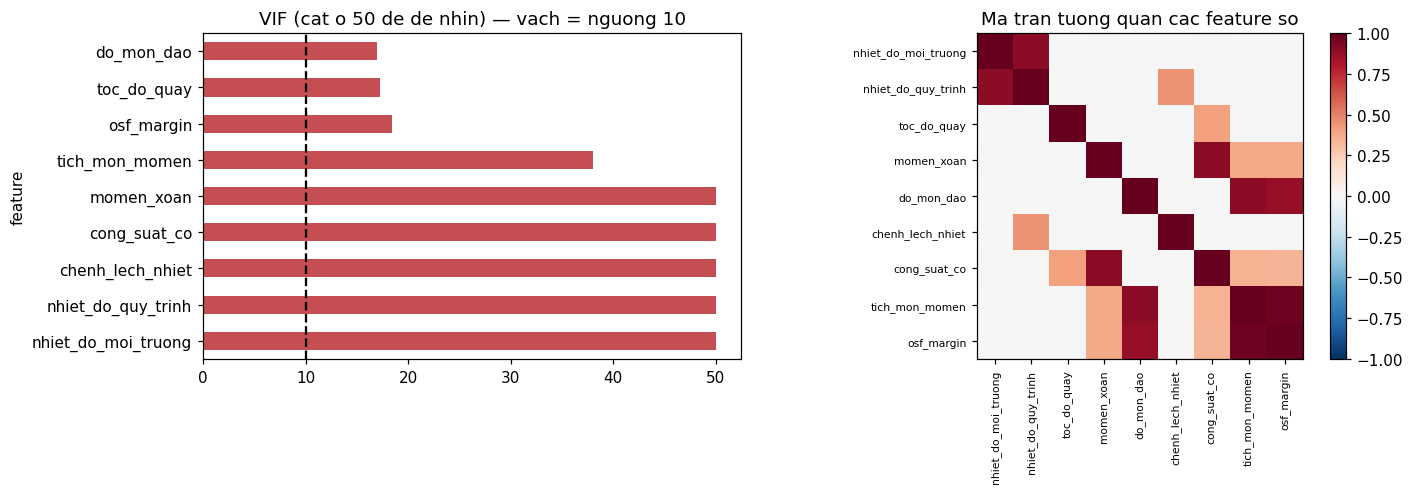

In [3]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
vif_df['VIF'].clip(upper=50).plot(kind='barh', ax=ax[0], color='#C44E52')   # clip 50 de cot inf khong pha bieu do
ax[0].axvline(10, ls='--', c='k'); ax[0].set_title('VIF (cat o 50 de de nhin) — vach = nguong 10')
c = np.corrcoef(train_fe[FINAL_NUM].values, rowvar=False)
im = ax[1].imshow(c, vmin=-1, vmax=1, cmap='RdBu_r')
ax[1].set_xticks(range(len(FINAL_NUM))); ax[1].set_xticklabels(FINAL_NUM, rotation=90, fontsize=7)
ax[1].set_yticks(range(len(FINAL_NUM))); ax[1].set_yticklabels(FINAL_NUM, fontsize=7)
ax[1].set_title('Ma tran tuong quan cac feature so'); fig.colorbar(im, ax=ax[1], fraction=.046)
plt.tight_layout(); plt.show()

In [4]:
# BANG CHUNG: cong tuyen lam HE SO LogReg khong on dinh. Chay LogReg tren 5 fold, xem he so lech bao nhieu.
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
skf = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
coefs = []
for tr_i, _ in skf.split(Z, y_train):
    # C=1e6 = phat cuc nho = GAN NHU KHONG regularize -> co tinh de lo ra su bat on do cong tuyen
    m = LogisticRegression(max_iter=2000, class_weight='balanced', C=1e6).fit(Z[tr_i], y_train[tr_i])
    coefs.append(m.coef_[0])
coefs = np.array(coefs)
inst = pd.DataFrame({'he_so_TB':coefs.mean(0), 'do_lech_giua_cac_fold':coefs.std(0)}, index=FINAL_NUM)
display(inst.round(3).sort_values('do_lech_giua_cac_fold', ascending=False))
print('Feature cong tuyen (VIF cao) thuong co he_so DAO DONG manh giua cac fold => khong on dinh.')

,he_so_TB,do_lech_giua_cac_fold
tich_mon_momen,0.643,0.161
momen_xoan,-2.933,0.156
do_mon_dao,0.111,0.137
cong_suat_co,2.822,0.120
osf_margin,0.082,0.062
toc_do_quay,-1.388,0.040
nhiet_do_moi_truong,0.073,0.016
nhiet_do_quy_trinh,-0.067,0.013
chenh_lech_nhiet,-0.293,0.011


Feature cong tuyen (VIF cao) thuong co he_so DAO DONG manh giua cac fold => khong on dinh.


> ### 🔎 Doc ket qua (Case 04)
> | Feature | VIF | Vi sao |
> |---|---|---|
> | bo 3 nhiet (moi_truong / quy_trinh / chenh_lech) | **∞** | `chenh_lech = quy_trinh − moi_truong` -> suy ra CHINH XAC, R²=1.0 |
> | `cong_suat_co` | ~96 | = momen × toc_do |
> | `momen_xoan` | ~83 | xuat hien trong nhieu feature phai sinh |
> | `tich_mon_momen` | ~38 | = mon × momen |
> | `osf_margin` | ~18 | phai sinh tu tich_mon_momen |
>
> Va he so LogReg **dao dong manh** giua cac fold (vd `momen` lech ±0.156) — dau hieu kinh dien cua cong tuyen.
>
> ### ✅ Ket luan Case 04
> Cong tuyen **chi hai LogReg**, **khong hai cay/rung** -> day chinh la ly do **RandomForest ben vung**.
> Vi vay ta **KHONG bo** cac feature phai sinh (chung van mang thong tin co che) — chi can **regularization L2/L1**
> cho model tuyen tinh (xem Case 05). Do la lua chon co can cu, khong phai bo feature mot cach may moc.